In [2]:
# building a basic chatbot using langgraph(graph api)

In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages # it will append the messages in any variable we will define instead of replacing it. and add_messages in a reducer which means it will not replace the messages. 

In [4]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages] # add the messages in list rather than overriding or replacing it

graph_builder = StateGraph(State) 

graph_builder

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from langchain_groq import ChatGroq

model = ChatGroq(
    model="openai/gpt-oss-120b",
)

In [7]:
# creating a node
def chatbot(state:State):
    return {"messages": [model.invoke(state["messages"])]}

# state["messages"] is the input message. and as soon as we are getting the messages we are  giving it to chatbot node and it will provide a response and will append that response it to "messages" which is defined in class above.


In [8]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot", chatbot)

## Adding Edges
graph_builder.add_edge(START, "llmchatbot") 
graph_builder.add_edge("llmchatbot", END)

# START -> llmchatbot -> END

#compile the graph to execute it.
graph = graph_builder.compile()

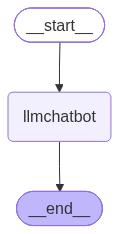

In [9]:
#visualizing the graph
from IPython.display import Image, display

try: 
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [10]:
response = graph.invoke({"messages": "Hi"})

In [11]:
response["messages"]

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='e731161e-2c77-41ed-9e36-425357565ca9'),
 AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi". We need to respond appropriately. It\'s a simple greeting. No policy issues. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 72, 'total_tokens': 116, 'completion_time': 0.091772716, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.002666533, 'prompt_tokens_details': None, 'queue_time': 0.366126212, 'total_time': 0.094439249}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_19b184c447', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a05caf-75ae-7872-8a80-2c3c6f9345f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 44, 'total_tokens': 116, 'output_token_detail

In [12]:
# This(response["messages"]) is the message variable that we had created in (messages: Annotated[list, add_messages] )
response["messages"][-1]

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi". We need to respond appropriately. It\'s a simple greeting. No policy issues. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 72, 'total_tokens': 116, 'completion_time': 0.091772716, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.002666533, 'prompt_tokens_details': None, 'queue_time': 0.366126212, 'total_time': 0.094439249}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_19b184c447', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a05caf-75ae-7872-8a80-2c3c6f9345f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 44, 'total_tokens': 116, 'output_token_details': {'reasoning': 26}})

In [13]:
response["messages"][-1].content

'Hello! How can I help you today?'

In [14]:
# or we can also display the message using stream
for event in graph.stream({"messages": "Hi how are you"}):
    print(event)

{'llmchatbot': {'messages': [AIMessage(content="Hello! I'm doing great, thank you for asking. How can I assist you today?", additional_kwargs={'reasoning_content': 'The user says "Hi how are you". We need to respond politely. No policy issues. Just a friendly response.'}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 75, 'total_tokens': 127, 'completion_time': 0.112901766, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.002897846, 'prompt_tokens_details': None, 'queue_time': 0.310112884, 'total_time': 0.115799612}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_6c36ac20de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a05caf-788a-7490-ba7e-523e792d8d87-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_tokens': 52, 'total_tokens': 127, 'output_token_details': {'reasoning': 25}})]}}


In [15]:
for event in graph.stream({"messages": "Hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm doing great, thank you. How can I help you today?


In [16]:
# creating chatbot with tool 
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results= 2)
tool.invoke("What is AI")

{'query': 'What is AI',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://cloud.google.com/learn/what-is-artificial-intelligence',
   'title': 'What is Artificial Intelligence (AI)?',
   'content': "Artificial intelligence (AI) is a set of technologies that empowers computers to learn, reason, and perform a variety of advanced tasks in ways that used to require human intelligence, such as understanding language, analyzing data, and even providing helpful suggestions. It’s a transformational technology that can bring meaningful and positive change to people and societies and the world. [...] Artificial intelligence techniques, though diverse, all fundamentally rely on data, algorithms, and computational power. AI systems learn and improve through exposure to vast amounts of data, identifying patterns and relationships that humans might miss. This data serves as the training material, the quality and quantity of which are crucial for the AI's per

In [17]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [18]:
tools=[tool, multiply]

In [19]:
llm_with_tool = model.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.11'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000025C01290920>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000025C0149D820>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, a

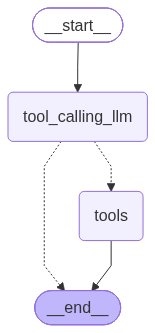

In [20]:
# Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


## Node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Grpah

builder=StateGraph(State)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


## Add Edges

builder.add_edge(START,"tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools",END)


## compile the graph

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
response = graph.invoke({"messages":"What is recent AI news"})

In [22]:
response

{'messages': [HumanMessage(content='What is recent AI news', additional_kwargs={}, response_metadata={}, id='7261c8c8-3bbb-4be4-b29b-04f48d9716a5'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks "What is recent AI news". Need to provide recent AI news. Should browse for latest AI news. Use search tool with query "latest AI news September 2026". Use time_range maybe "day" or "week".', 'tool_calls': [{'id': 'fc_a067da97-4666-494f-ab4b-3518dbad8622', 'function': {'arguments': '{"query":"latest AI news September 2026","search_depth":"advanced","time_range":"day"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 347, 'total_tokens': 447, 'completion_time': 0.208897613, 'completion_tokens_details': {'reasoning_tokens': 49}, 'prompt_time': 0.048355638, 'prompt_tokens_details': None, 'queue_time': 0.369898761, 'total_time': 0.257253251}, 'model_name': 'openai/gpt-oss-120b', 'system_fing

In [23]:
response['messages'][-1].content

'{"query": "latest AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://unrot.co/blogs/today-top-ai-news-september-1-2026", "title": "Top AI News Today: Sept 1 (13 Stories) - unrot.co", "content": "retired by the end of August. Kimi K3 has been publicly available since July 27, 2026, and remains the top ranked open weight model on independent tracker Artificial Analysis, with an Intelligence Index of 60.\\n\\nRetiring the older, cheaper models the same month a pricier flagship becomes the only option is a notable bet by Moonshot: Kimi K3 costs roughly five times more per token than its predecessor, reversing a year of Chinese labs competing mainly on rock bottom prices. Moonshot appears to be betting that developers value K3\'s performance, which currently ranks second on the WebDev Arena leaderboard and third on the Agent leaderboard, enough to accept the higher cost. [...] ### References\\n\\nApple hands over to new CEO John

In [24]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_a067da97-4666-494f-ab4b-3518dbad8622)
 Call ID: fc_a067da97-4666-494f-ab4b-3518dbad8622
  Args:
    query: latest AI news September 2026
    search_depth: advanced
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://unrot.co/blogs/today-top-ai-news-september-1-2026", "title": "Top AI News Today: Sept 1 (13 Stories) - unrot.co", "content": "retired by the end of August. Kimi K3 has been publicly available since July 27, 2026, and remains the top ranked open weight model on independent tracker Artificial Analysis, with an Intelligence Index of 60.\n\nRetiring the older, cheape

In [25]:
response = graph.invoke({"messages":"What is 2 multiply by 3"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_1888ebff-e8f0-4f1f-a9f7-25c4700addd0)
 Call ID: fc_1888ebff-e8f0-4f1f-a9f7-25c4700addd0
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [26]:
response = graph.invoke({"messages":"Give me the recent AI news and then multiply 2 by 3"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then multiply 2 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_dad74803-d52e-4723-a8a9-39e61b3fc234)
 Call ID: fc_dad74803-d52e-4723-a8a9-39e61b3fc234
  Args:
    query: latest AI news September 2026
    search_depth: advanced
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://unrot.co/blogs/today-top-ai-news-september-1-2026", "title": "Top AI News Today: Sept 1 (13 Stories) - unrot.co", "content": "retired by the end of August. Kimi K3 has been publicly available since July 27, 2026, and remains the top ranked open weight model on independent tracker Artificial Analysis, with an Intelligence Index of 60.\

In [27]:
# LLM gave the result of tavily search but not of the second question. 
# https://youtu.be/rV3HJ4LEZ7k?si=NKjhbyKTspj7rWmg&t=13982

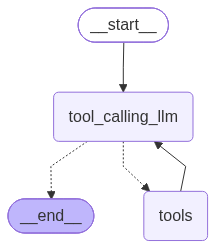

In [28]:
# using reAct agent architecture

# Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


## Node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Grpah

builder=StateGraph(State)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


## Add Edges

builder.add_edge(START,"tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

# builder.add_edge("tools",END) instead of going to END, it will go abck to tool calling llm
builder.add_edge("tools","tool_calling_llm")


## compile the graph

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
response = graph.invoke({"messages":"Give me the recent AI news and then multiply 2 by 3"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then multiply 2 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_4b03fdc7-7c15-4c50-ad48-b53fe6c9a634)
 Call ID: fc_4b03fdc7-7c15-4c50-ad48-b53fe6c9a634
  Args:
    query: AI news September 2026
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://aitoolsrecap.com/Blog/AINewsSeptember2026.aspx", "title": "Latest AI News September 2026: Daily AI News, Updates & Breaking Stories Today | AIToolsRecap", "content": "# AI News: September 2026\n\nEvery daily roundup for September 2026 — model releases, announcements, pricing changes, and AI updates. Click any highlighted date to read that day's r

In [30]:
# adding the memory
response = graph.invoke({"messages":"Hello my name is Ritesh"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Ritesh
================================== Ai Message ==================================

Hello Ritesh! Nice to meet you. How can I assist you today?


In [31]:
response = graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I’m sorry, but I don’t have any information about your name. If you’d like me to address you a certain way, just let me know!


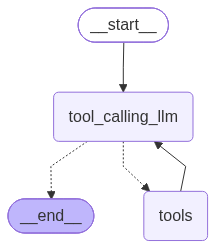

In [32]:
# It is not persisting the entire information wrt to previous conversation. so memory solve this persistence

# Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Grpah

builder=StateGraph(State)

builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))


## Add Edges

builder.add_edge(START,"tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

# builder.add_edge("tools",END) instead of going to END, it will go abck to tool calling llm
builder.add_edge("tools","tool_calling_llm")


## compile the graph

graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
# if we want to use this specific memory for context of the previous interaction, so for this we need to create a thread id

config={"configurable":{"thread_id": "1"}}
response = graph.invoke({"messages": "My name is Ritesh"}, config=config)
response

{'messages': [HumanMessage(content='My name is Ritesh', additional_kwargs={}, response_metadata={}, id='2e21d356-1091-41df-bbd7-8fb9a9023b01'),
  AIMessage(content="Nice to meet you, Ritesh! If there's anything I can help you with, just let me know.", additional_kwargs={'reasoning_content': 'The user says "My name is Ritesh". Probably they want me to acknowledge. There\'s no question. I should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 348, 'total_tokens': 408, 'completion_time': 0.12473741, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.01519533, 'prompt_tokens_details': None, 'queue_time': 0.363772764, 'total_time': 0.13993274}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c868cf1eaa', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a05caf-e8f7-74f0-a64e-93fd1365bf2a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata=

In [34]:
response["messages"][-1].content

"Nice to meet you, Ritesh! If there's anything I can help you with, just let me know."

In [35]:
response = graph.invoke({"messages": "What is my name"}, config=config)
response["messages"][-1].content

'You told me your name is **Ritesh**.'

In [36]:
# streaming in langgraph
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [37]:
def superbot(state: State):
    return {"messages": [model.invoke(state["messages"])]}

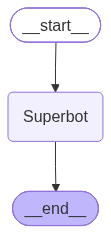

In [38]:
graph = StateGraph(State)

# node
graph.add_node("Superbot", superbot)

# edge
graph.add_edge(START, "Superbot")
graph.add_edge("Superbot", END)

graph_builder = graph.compile(checkpointer=memory)

# display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [39]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket."},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket.', additional_kwargs={}, response_metadata={}, id='efdc1f13-6fdf-4b86-8b51-1d4c2302b620'),
  AIMessage(content='Hi Krish! 👋 Great to meet you. Cricket is such an exciting sport—do you have a favorite team or player? How can I help you today?', additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Krish And I like cricket." There\'s no question. Likely a greeting. Should respond politely, ask how can I help. Possibly engage about cricket. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 83, 'total_tokens': 172, 'completion_time': 0.185677113, 'completion_tokens_details': {'reasoning_tokens': 46}, 'prompt_time': 0.030248134, 'prompt_tokens_details': None, 'queue_time': 0.490023974, 'total_time': 0.215925247}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_19b184c447', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprob

In [40]:
# https://youtu.be/rV3HJ4LEZ7k?si=5PlcRo8FXWMo4rLX&t=15077

In [41]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({"messages":"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

# we did not get the human message, which one was the last message we got that.

{'Superbot': {'messages': [AIMessage(content="Hello Krish! Nice to meet you. 😊\n\nCricket is such an exciting sport—do you have a favorite team or player? Are you more into the fast‑bowling action, the strategic spin game, or maybe the thrilling T20 format? I'd love to hear more about what you enjoy most about cricket!", additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Krish And I like cricket". Likely they are greeting and sharing info. The assistant should respond politely, maybe ask about cricket preferences, etc. No policy issues. Should respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 82, 'total_tokens': 205, 'completion_time': 0.254393269, 'completion_tokens_details': {'reasoning_tokens': 49}, 'prompt_time': 0.003307762, 'prompt_tokens_details': None, 'queue_time': 0.158339952, 'total_time': 0.257701031}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5a93aea882', 'service_tier': 'on_demand',

In [42]:
# changing mode = values
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({"messages":"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

# In this AI message got also appended.

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='b806dd16-29d6-453a-a55c-1feb72a6b888'), AIMessage(content="Hello Krish! Nice to meet you. 😊\n\nCricket is such an exciting sport—do you have a favorite team or player? Are you more into the fast‑bowling action, the strategic spin game, or maybe the thrilling T20 format? I'd love to hear more about what you enjoy most about cricket!", additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Krish And I like cricket". Likely they are greeting and sharing info. The assistant should respond politely, maybe ask about cricket preferences, etc. No policy issues. Should respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 82, 'total_tokens': 205, 'completion_time': 0.254393269, 'completion_tokens_details': {'reasoning_tokens': 49}, 'prompt_time': 0.003307762, 'prompt_tokens_details': None, 'queue_time': 0.15833

In [43]:
# astream method
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":" I also like basketball"},config, version="v2"):
    print(event)

# for debugging it helps to understand all the events.

{'event': 'on_chain_start', 'data': {'input': {'messages': ' I also like basketball'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a05caf-f623-7bb0-870f-432da52fde54', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content=' I also like basketball', additional_kwargs={}, response_metadata={}, id='b347f30c-bde3-4e68-a7eb-e57b8bad3f47')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '01a05caf-f62b-7a72-ad5e-078741d93b5f', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:6a2cea37-4ac8-aae9-2cd5-2c395ebce2c4'}, 'parent_ids': ['01a05caf-f623-7bb0-870f-432da52fde54']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content=' I also like basketball

In [44]:
# Human in hte loop

from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt


class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)


@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]


tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]

llm_with_tools = model.bind_tools(tools)


def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])

    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.

    return {"messages": [message]}


graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)


graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")



In [45]:
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

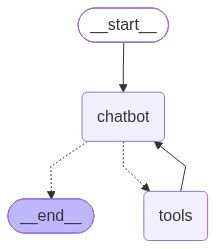

In [46]:
from IPython.display import Image, display
try: 
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [47]:
user_input = "I need some expert guidance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_d53af7f9-f66b-4644-a99f-f3dc2cb61d94)
 Call ID: fc_d53af7f9-f66b-4644-a99f-f3dc2cb61d94
  Args:
    query: User requests expert guidance for building an AI agent. Please provide assistance.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_d53af7f9-f66b-4644-a99f-f3dc2cb61d94)
 Call ID: fc_d53af7f9-f66b-4644-a99f-f3dc2cb61d94
  Args:
    query: User requests expert guidance for building an AI agent. Please provide assistance.


In [ ]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistence for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_63921b31-c06c-40b3-8fd3-5842d41f13ca)
 Call ID: fc_63921b31-c06c-40b3-8fd3-5842d41f13ca
  Args:
    query: User is seeking expert guidance and assistance for building an AI agent. Please provide detailed support and resources.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_63921b31-c06c-40b3-8fd3-5842d41f13ca)
 Call ID: fc_63921b31-c06c-40b3-8fd3-5842d41f13ca
  Args:
    query: User is seeking expert guidance and assistance for building an AI agent. Please provide detailed support and resources.


In [ ]:
# now it is expecting humans to provide some kind of input back. 
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_63921b31-c06c-40b3-8fd3-5842d41f13ca)
 Call ID: fc_63921b31-c06c-40b3-8fd3-5842d41f13ca
  Args:
    query: User is seeking expert guidance and assistance for building an AI agent. Please provide detailed support and resources.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

Absolutely—happy to help you get started building a robust AI agent! Below is a practical, step‑by‑step guide that covers the core concepts, tools, and best‑practice patterns you’ll want to consider. I’ve organized it into four main phases:

---

## 1️⃣ Define the Agent’s Purpose & Scope

| Question | Why